## Prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel(r"D:\2-zindua\03-python-data-analysis\zindua-python-data-analysis\wk2_pandas\QVI_transaction_data (2).xlsx")

data = pd.read_csv(r"D:\2-zindua\03-python-data-analysis\zindua-python-data-analysis\wk2_pandas\QVI_purchase_behaviour (1).csv")

In [3]:
full_df = data.merge(df, how='left',on='LYLTY_CARD_NBR')
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264836 non-null  int64  
 1   LIFESTAGE         264836 non-null  object 
 2   PREMIUM_CUSTOMER  264836 non-null  object 
 3   DATE              264836 non-null  int64  
 4   STORE_NBR         264836 non-null  int64  
 5   TXN_ID            264836 non-null  int64  
 6   PROD_NBR          264836 non-null  int64  
 7   PROD_NAME         264836 non-null  object 
 8   PROD_QTY          264836 non-null  int64  
 9   TOT_SALES         264836 non-null  float64
dtypes: float64(1), int64(6), object(3)
memory usage: 20.2+ MB


In [4]:
full_df['New_Date'] = pd.to_numeric(full_df['DATE'])

In [5]:
full_df['DATE'] = pd.to_datetime(full_df['DATE'], origin='1899-12-31', unit='D')
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   LYLTY_CARD_NBR    264836 non-null  int64         
 1   LIFESTAGE         264836 non-null  object        
 2   PREMIUM_CUSTOMER  264836 non-null  object        
 3   DATE              264836 non-null  datetime64[ns]
 4   STORE_NBR         264836 non-null  int64         
 5   TXN_ID            264836 non-null  int64         
 6   PROD_NBR          264836 non-null  int64         
 7   PROD_NAME         264836 non-null  object        
 8   PROD_QTY          264836 non-null  int64         
 9   TOT_SALES         264836 non-null  float64       
 10  New_Date          264836 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(3)
memory usage: 22.2+ MB


In [6]:
full_df.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,New_Date
0,1000,YOUNG SINGLES/COUPLES,Premium,2018-10-18,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,43390
1,1002,YOUNG SINGLES/COUPLES,Mainstream,2018-09-17,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,43359
2,1003,YOUNG FAMILIES,Budget,2019-03-08,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,43531
3,1003,YOUNG FAMILIES,Budget,2019-03-09,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,43532
4,1004,OLDER SINGLES/COUPLES,Mainstream,2018-11-03,1,5,96,WW Original Stacked Chips 160g,1,1.9,43406


## Assignment
### Your goal is to move beyond the numbers and visualize the following key insights:
- Trends: How have sales evolved over time?
- Segmentation: What is the total sales breakdown by Lifestage and Premium Customer level?
- Outliers: What does the distribution of total sales look like? Identify any specific outliers.
- Comparisons: Does the distribution of sales differ significantly across Lifestages?
- Volume: Which premium customer groups contribute most to the total quantity sold?
- Brand Loyalty: Which chip brand is the market leader?
- Correlation: Explore the relationship between Total Sales and Product Quantity. Does this correlation shift depending on the Lifestage?

#### Styling

In [7]:
line_styles = dict(marker='.',
                   markersize=10,
                   markerfacecolor='blue',
                   markeredgecolor='white',
                   linestyle='solid',
                   linewidth=.5)

#### Trends:
How have sales evolved over time?

In [8]:
sales_trends = full_df.groupby('DATE')['TOT_SALES'].sum()

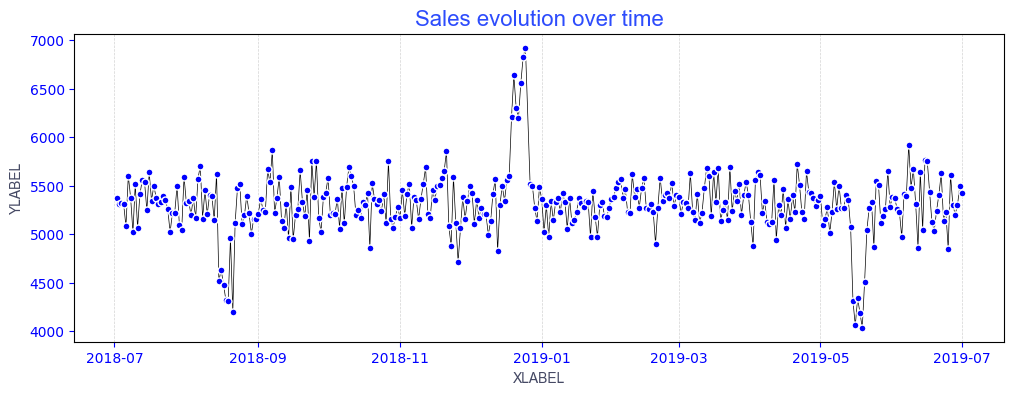

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(sales_trends,
         **line_styles,     #unpacking the dict of line styles
         color='black')
plt.grid(axis='x',
         linewidth=.5,
         color='lightgrey',
         linestyle='dashed')
plt.title("Sales evolution over time",
           fontsize=16,
           family='Arial',
           fontweight=400,
           color='#2d4cfc')
plt.xlabel("XLABEL", 
           fontsize=10,
           family='Arial',
           fontweight=400,
           color="#454964")
#plt.xticks([])  # hides all xticks
plt.xticks()
plt.ylabel("YLABEL", 
           fontsize=10,
           family='Arial',
           fontweight=400,
           color="#454964")
plt.tick_params(axis='both',
                colors='blue')

plt.show()

In [18]:
txn_trends = full_df.groupby('DATE')['TOT_SALES'].count()

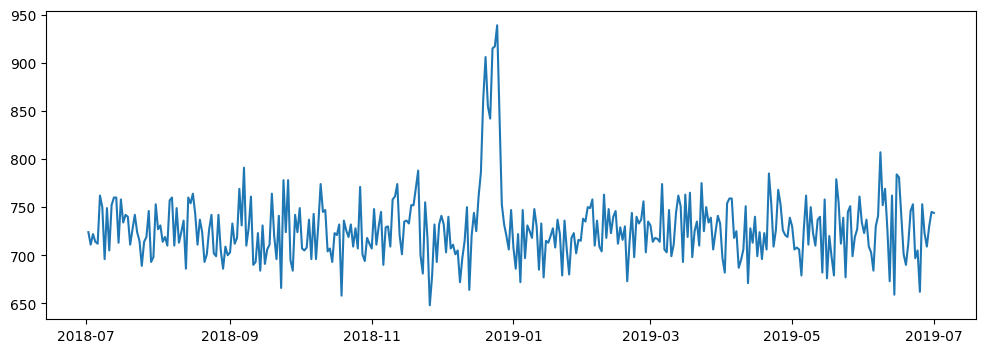

In [19]:
plt.figure(figsize=(12,4))

plt.plot(txn_trends)

plt.show()

#### Segmentation:
What is the total sales breakdown by Lifestage and Premium Customer level?

In [63]:
lifestyle_sales = full_df.groupby('LIFESTAGE')[['TOT_SALES']].sum().sort_values(by='TOT_SALES').reset_index()
lifestyle_sales

,LIFESTAGE,TOT_SALES
0,NEW FAMILIES,50433.45
1,MIDAGE SINGLES/COUPLES,184751.30
2,YOUNG SINGLES/COUPLES,260405.30
3,YOUNG FAMILIES,316160.10
4,OLDER FAMILIES,353767.20
5,RETIREES,366470.90
6,OLDER SINGLES/COUPLES,402426.75


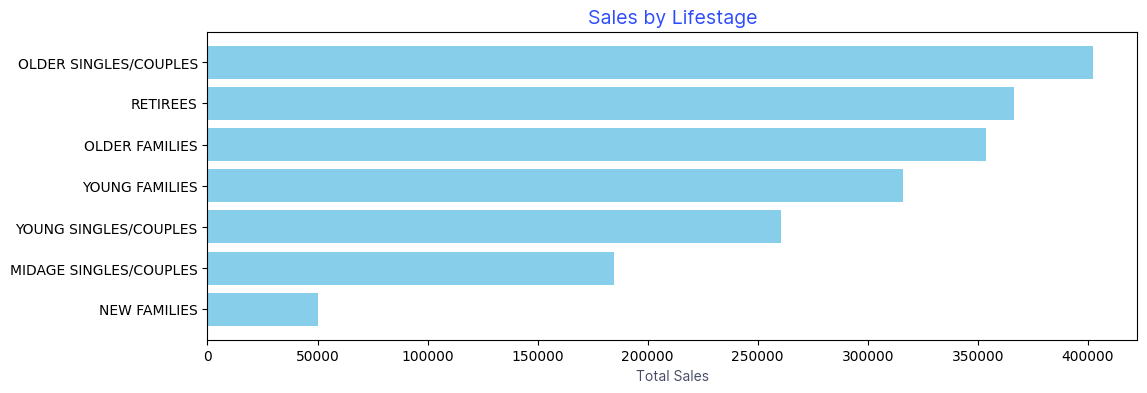

In [61]:
# bar charts: plt.bar(categories, values)

plt.figure(figsize=(12,4))

plt.barh(lifestyle_sales['LIFESTAGE'],lifestyle_sales['TOT_SALES'], color='skyblue')
plt.title("Sales by Lifestage",
           fontsize=14,
           family='Inter',
           fontweight=400,
           color='#2d4cfc')
plt.xlabel("Total Sales",
           family='Inter',
           color="#454964")

plt.show()

#### Outliers:
What does the distribution of total sales look like? Identify any specific outliers.

In [23]:
full_df.describe()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,New_Date
count,2.648360e+05,264836,264836.00000,2.648360e+05,264836.000000,264836.000000,264836.000000,264836.000000
mean,1.355495e+05,2018-12-31 00:52:12.879215616,135.08011,1.351583e+05,56.583157,1.907309,7.304200,43464.036260
min,1.000000e+03,2018-07-02 00:00:00,1.00000,1.000000e+00,1.000000,1.000000,1.500000,43282.000000
25%,7.002100e+04,2018-10-01 00:00:00,70.00000,6.760150e+04,28.000000,2.000000,5.400000,43373.000000
50%,1.303575e+05,2018-12-31 00:00:00,130.00000,1.351375e+05,56.000000,2.000000,7.400000,43464.000000
75%,2.030942e+05,2019-04-01 00:00:00,203.00000,2.027012e+05,85.000000,2.000000,9.200000,43555.000000
max,2.373711e+06,2019-07-01 00:00:00,272.00000,2.415841e+06,114.000000,200.000000,650.000000,43646.000000
std,8.057998e+04,NaN,76.78418,7.813303e+04,32.826638,0.643654,3.083226,105.389282


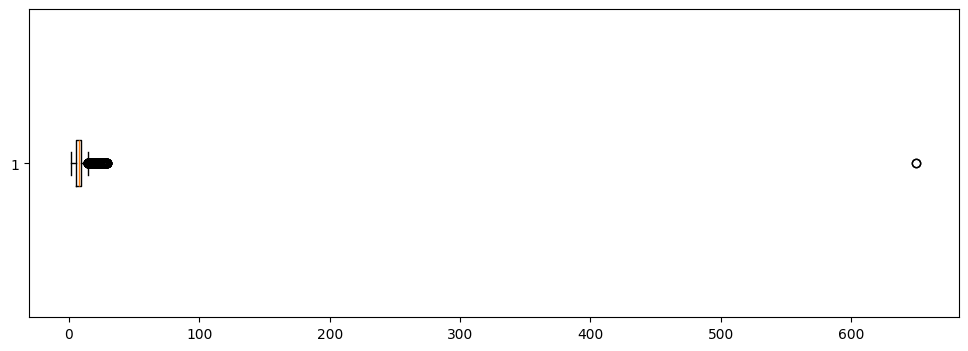

In [13]:
# first visualise what the distribution looks like

plt.figure(figsize=(12,4))

plt.boxplot(data=full_df, x='TOT_SALES', vert=False)

plt.show()

In [46]:
# then create your mask based on where the outliers were

not_out = full_df[full_df['TOT_SALES'] < 50]
not_out.describe()

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES,New_Date
count,2.648340e+05,264834,264834.000000,2.648340e+05,264834.000000,264834.000000,264834.000000,264834.000000
mean,1.355488e+05,2018-12-31 00:52:10.292937984,135.079423,1.351576e+05,56.583554,1.905813,7.299346,43464.036230
min,1.000000e+03,2018-07-02 00:00:00,1.000000,1.000000e+00,1.000000,1.000000,1.500000,43282.000000
25%,7.002100e+04,2018-10-01 00:00:00,70.000000,6.760050e+04,28.000000,2.000000,5.400000,43373.000000
50%,1.303570e+05,2018-12-31 00:00:00,130.000000,1.351365e+05,56.000000,2.000000,7.400000,43464.000000
75%,2.030940e+05,2019-04-01 00:00:00,203.000000,2.026998e+05,85.000000,2.000000,9.200000,43555.000000
max,2.373711e+06,2019-07-01 00:00:00,272.000000,2.415841e+06,114.000000,5.000000,29.500000,43646.000000
std,8.057990e+04,NaN,76.784063,7.813292e+04,32.826444,0.343436,2.527241,105.389007


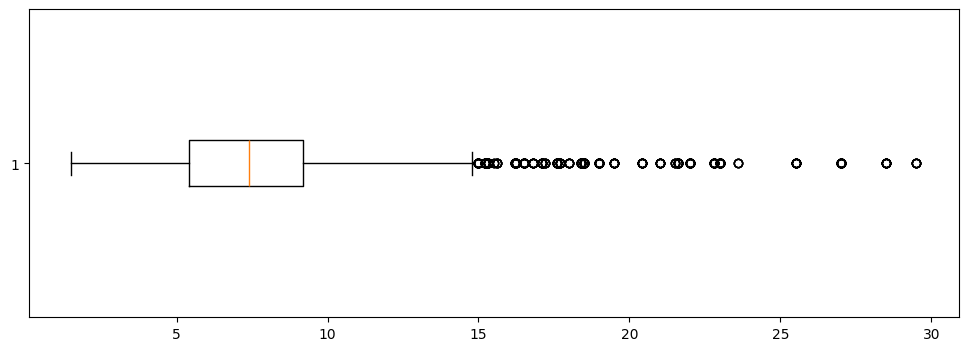

In [25]:
plt.figure(figsize=(12,4))

plt.boxplot(not_out['TOT_SALES'], vert=False)

plt.show()

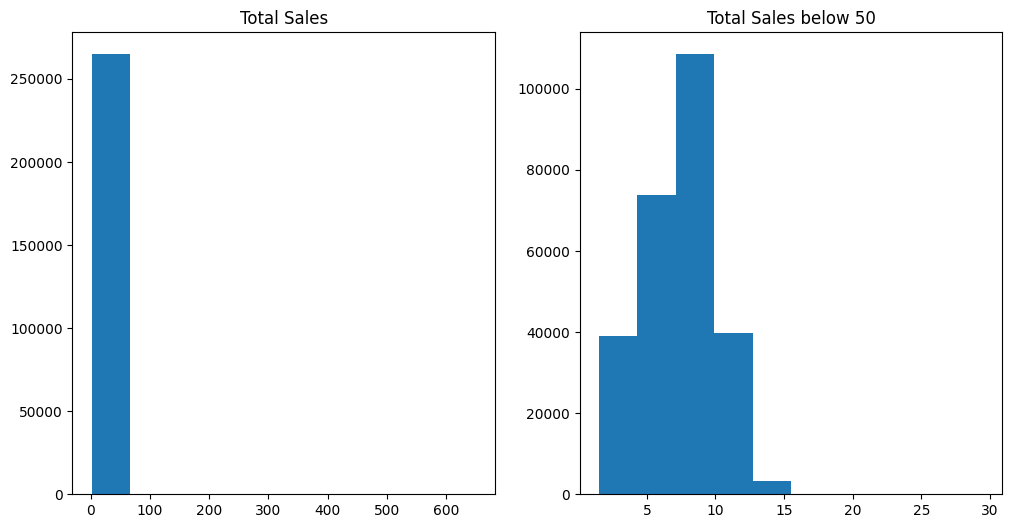

In [ ]:
fig,ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6))

ax[0].hist(full_df['TOT_SALES'])
ax[0].set_title('Total Sales')
ax[1].hist(not_out['TOT_SALES'])
ax[1].set_title('Total Sales below 50')

plt.show()

#### Comparisons:
Does the distribution of sales differ significantly across Lifestages?

In [68]:
lifestage_df = full_df.groupby('LIFESTAGE')['TOT_SALES'].count().sort_values().reset_index()
lifestage_df

,LIFESTAGE,TOT_SALES
0,NEW FAMILIES,6919
1,MIDAGE SINGLES/COUPLES,25110
2,YOUNG SINGLES/COUPLES,36377
3,YOUNG FAMILIES,43592
4,OLDER FAMILIES,48596
5,RETIREES,49763
6,OLDER SINGLES/COUPLES,54479


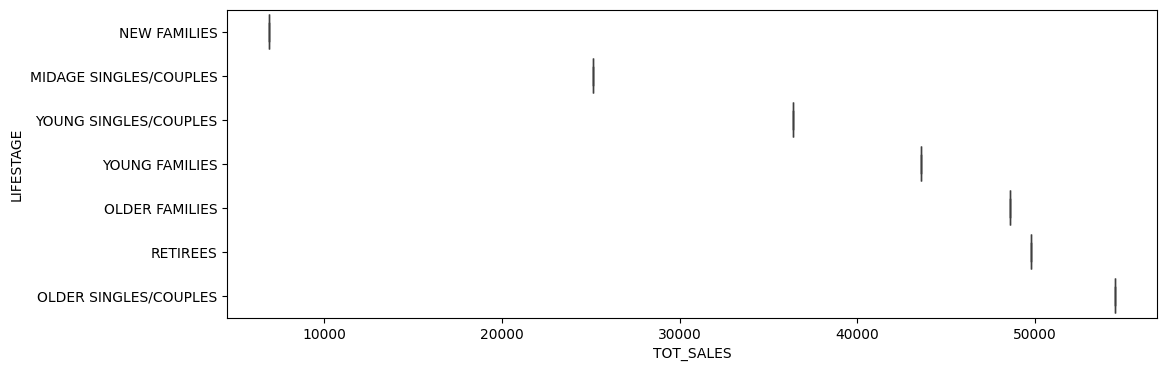

In [69]:
plt.figure(figsize=(12,4))

# plt.boxplot(lifestage_df['TOT_SALES'], vert=False)
sns.boxplot(data=lifestage_df, y='LIFESTAGE', x='TOT_SALES', orientation='horizontal')

plt.show()

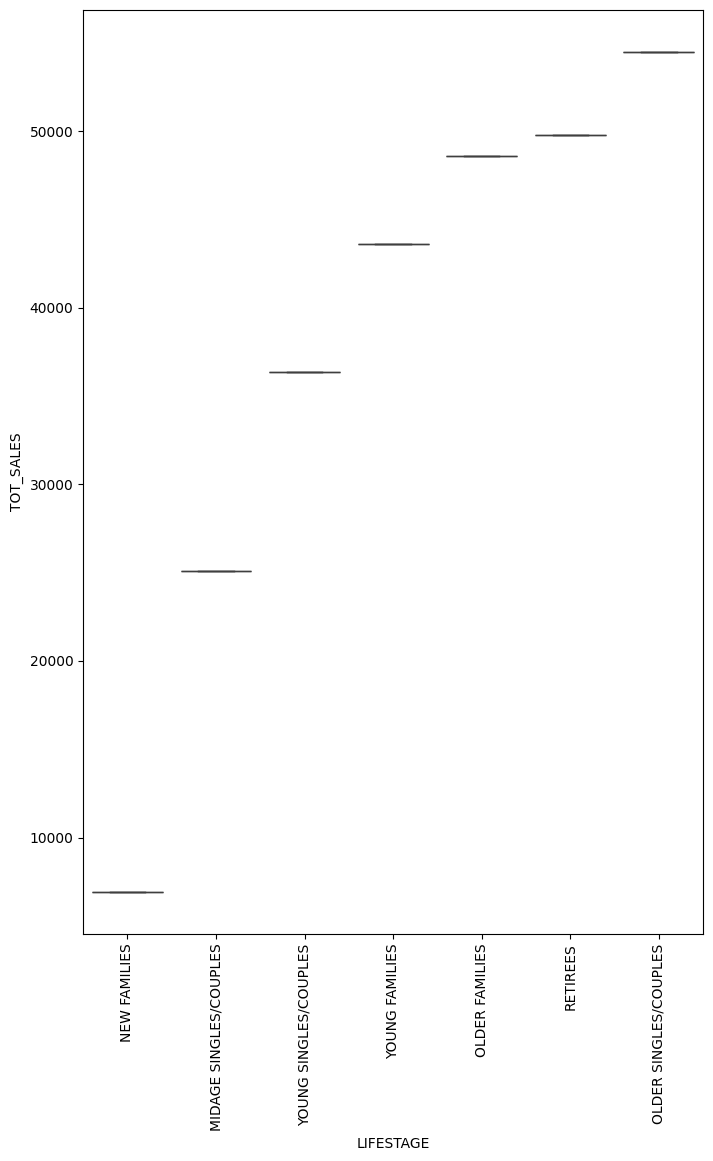

In [70]:
plt.figure(figsize=(8,12))

sns.boxplot(data=lifestage_df, x='LIFESTAGE', y='TOT_SALES')
plt.xticks(rotation=90)

plt.show()

#### Volume:
Which premium customer groups contribute most to the total quantity sold?

In [72]:
premium_sales = full_df.groupby('PREMIUM_CUSTOMER')['PROD_QTY'].sum().reset_index()
premium_sales

,PREMIUM_CUSTOMER,PROD_QTY
0,Budget,177898
1,Mainstream,193965
2,Premium,133261


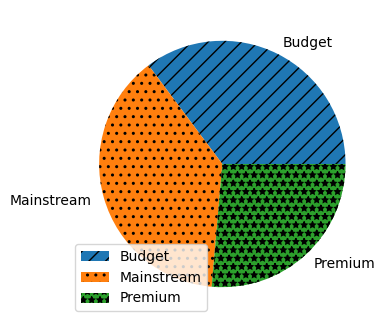

In [ ]:
plt.figure(figsize=(12,4))

plt.pie(premium_sales['PROD_QTY'],
        labels=premium_sales['PREMIUM_CUSTOMER'],
        hatch=['//','..','**'])
plt.legend()

plt.show()

#### Brand Loyalty:
Which chip brand is the market leader?

In [96]:
chip_brands = full_df.groupby('PROD_NAME')['TOT_SALES'].sum().sort_values(ascending=True).reset_index().loc[0:4]
chip_brands

,PROD_NAME,TOT_SALES
0,Woolworths Medium Salsa 300g,4050.0
1,Woolworths Mild Salsa 300g,4234.5
2,WW Crinkle Cut Original 175g,4532.2
3,Sunbites Whlegrn Crisps Frch/Onin 90g,4600.2
4,WW Crinkle Cut Chicken 175g,4702.2


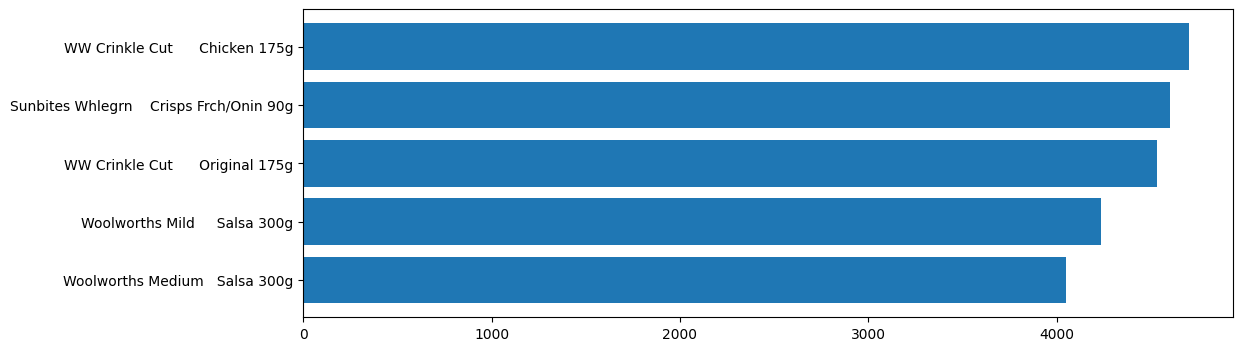

In [97]:
plt.figure(figsize=(12,4))

plt.barh(y=chip_brands['PROD_NAME'], width=chip_brands['TOT_SALES'])
plt.show()

In [ ]:
brand_name = r'()'

full_df['PROD_BRAND'] = full_df['PROD_NAME'].str.extract(brand_name)

#### Correlation:
Explore the relationship between Total Sales and Product Quantity. Does this correlation shift depending on the Lifestage?